In [10]:
import pandas as pd
import numpy as np
import cooltools
import cooler
import os
from scipy import stats
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

## Coverage analysis

In [11]:
data_dir = '/tank/projects/kashuk_sirt6_hic/coolers/'
wt1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_2_50k.cool'))
wt2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_3_50k.cool'))
wt3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_m_1_50k.cool'))

old1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_2_50k.cool'))
old2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_3_50k.cool'))
old3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_m_1_50k.cool'))

ko1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_2_50k.cool'))
ko2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_3_50k.cool'))
ko3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_m_1_50k.cool'))

ref_fasta = ('/tank/projects/kashuk_sirt6_hic/GRCm38.p6.genome.fa')

#### Adult vs S6-KO

In [12]:
bins_wt1 = wt1.bins()[:]
bins_wt2 = wt2.bins()[:]
bins_wt3 = wt3.bins()[:]

In [13]:
bins_ko1 = ko1.bins()[:]
bins_ko2 = ko2.bins()[:]
bins_ko3 = ko3.bins()[:]

In [14]:
coverage_wt1 = wt1.matrix(balance=False)[:].sum(axis=1)
coverage_wt2 = wt2.matrix(balance=False)[:].sum(axis=1)
coverage_wt3 = wt3.matrix(balance=False)[:].sum(axis=1)

coverage_ko1 = ko1.matrix(balance=False)[:].sum(axis=1)
coverage_ko2 = ko2.matrix(balance=False)[:].sum(axis=1)
coverage_ko3 = ko3.matrix(balance=False)[:].sum(axis=1)

coverage_df = pd.DataFrame({
    'chrom': bins_wt1['chrom'],
    'start': bins_wt1['start'],
    'end': bins_wt1['end'],
    'coverage_wt1': coverage_wt1,
    'coverage_wt2': coverage_wt2,
    'coverage_wt3': coverage_wt3,
    'coverage_ko1': coverage_ko1,
    'coverage_ko2': coverage_ko2,
    'coverage_ko3': coverage_ko3
})

In [15]:
compartments = pd.read_csv('Adult->S6-KO_bins.csv', index_col = 0)
stable_bins = pd.read_csv('Adult->S6-KO_stable_bins.csv', index_col = 0)

In [16]:
full_compartments = pd.concat([compartments, stable_bins])

In [17]:
merged_df = pd.merge(full_compartments, coverage_df, on=['chrom', 'start', 'end'])

In [18]:
merged_df['mean_coverage'] = merged_df[["coverage_wt1", 
                                        "coverage_wt2", 
                                        "coverage_wt3", 
                                        "coverage_ko1", 
                                        "coverage_ko2", 
                                        "coverage_ko3"]].mean(axis = 1)

merged_df['mean_coverage_log10'] = np.log10(merged_df['mean_coverage'])

merged_df

,chrom,start,end,Label,coverage_wt1,coverage_wt2,coverage_wt3,coverage_ko1,coverage_ko2,coverage_ko3,mean_coverage,mean_coverage_log10
0,chr1,119200000,119250000,A->B,2359.0,2352.0,2278.0,2238.0,2026.0,2120.0,2228.833333,3.348078
1,chr1,120050000,120100000,A->B,2425.0,2346.0,2528.0,2341.0,2231.0,2338.0,2368.166667,3.374412
2,chr2,172850000,172900000,A->B,2170.0,2047.0,2112.0,1992.0,1835.0,2022.0,2029.666667,3.307425
3,chr3,8500000,8550000,A->B,2038.0,2026.0,2070.0,1980.0,1922.0,2192.0,2038.000000,3.309204
4,chr3,36350000,36400000,A->B,2232.0,2218.0,2167.0,2172.0,2186.0,2296.0,2211.833333,3.344752
...,...,...,...,...,...,...,...,...,...,...,...,...
46252,chr19,59150000,59200000,stable_AB,2292.0,2253.0,2285.0,2147.0,2009.0,2254.0,2206.666667,3.343737
46253,chr19,59200000,59250000,stable_AB,2484.0,2357.0,2490.0,2398.0,2302.0,2444.0,2412.500000,3.382467
46254,chr19,59250000,59300000,stable_AB,2512.0,2371.0,2602.0,2478.0,2469.0,2507.0,2489.833333,3.396170
46255,chr19,60500000,60550000,stable_AB,2271.0,2247.0,2285.0,2254.0,2187.0,2289.0,2255.500000,3.353243


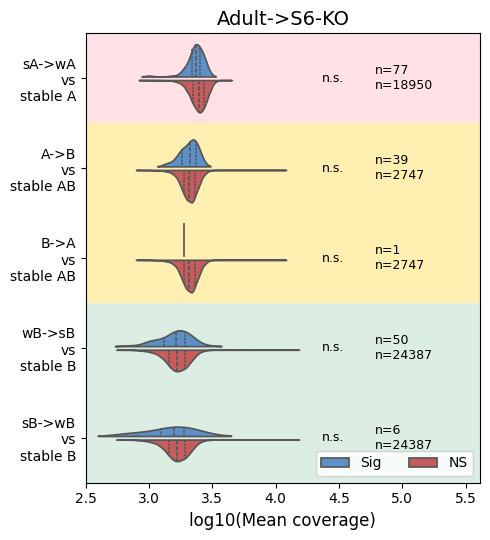

In [23]:
target_control_pairs = {
    'A->B': 'stable_AB',
    'B->A': 'stable_AB',
    'wB->sB': 'stable_B',
    'sB->wB': 'stable_B',
    'sA->wA': 'stable_A'
}

group_colors = {
    'B transitions': '#A8D5BA',      # Light green
    'A-B transitions': '#FFD93D',    # Yellow
    'A transitions': '#FFB6C1'       # Light pink
}

label_to_group = {
    'wB->sB': 'B transitions', 'sB->wB': 'B transitions', 'stable_B': 'B transitions',
    'A->B': 'A-B transitions', 'B->A': 'A-B transitions', 'stable_AB': 'A-B transitions',
    'sA->wA': 'A transitions', 'stable_A': 'A transitions'
}

paired_data = []
pair_order = ['sA->wA', 'A->B', 'B->A', 'wB->sB', 'sB->wB']  

def get_significance_label(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.0001:
        return '****'
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'n.s.'

stat_results = {}

for target in pair_order:
    control = target_control_pairs[target]
    
    target_data = merged_df[merged_df['Label'] == target]['mean_coverage_log10'].dropna().values
    control_data = merged_df[merged_df['Label'] == control]['mean_coverage_log10'].dropna().values
    n1, n2 = len(target_data), len(control_data)
    
    res_dict = {
        'u_stat': np.nan,
        'p_value': np.nan,
        'effect_size': np.nan,
        'effect_interp': "N/A",
        'n_target': n1,
        'n_control': n2,
        'sig_label': 'N/A',
        'median_target': np.nan,
        'median_control': np.nan
    }
    
    if n1 > 0 and n2 > 0:
        u_stat, p_value = stats.mannwhitneyu(target_data, control_data, alternative='two-sided')
        
        r_effect = 1 - (2 * u_stat) / (n1 * n2) 
        
        if abs(r_effect) < 0.1:
            effect_interp = "negligible"
        elif abs(r_effect) < 0.3:
            effect_interp = "small"
        elif abs(r_effect) < 0.5:
            effect_interp = "medium"
        else:
            effect_interp = "large"
            
        res_dict.update({
            'u_stat': u_stat,
            'p_value': p_value,
            'effect_size': r_effect,
            'effect_interp': effect_interp,
            'sig_label': get_significance_label(p_value),
            'median_target': np.median(target_data),
            'median_control': np.median(control_data)
        })
        
    stat_results[target] = res_dict

valid_raw_p = [stat_results[t]['p_value'] for t in pair_order if pd.notna(stat_results[t]['p_value'])]

if valid_raw_p:
    _, p_adj_vals, _, _ = multipletests(valid_raw_p, alpha=0.05, method='fdr_bh')
    
    adj_idx = 0
    for target in pair_order:
        if pd.notna(stat_results[target]['p_value']):
            p_adj = p_adj_vals[adj_idx]
            stat_results[target]['p_adj'] = p_adj
            stat_results[target]['sig_label'] = get_significance_label(p_adj)
            adj_idx += 1

for target, control in target_control_pairs.items():
    target_df = merged_df[merged_df['Label'] == target].copy()
    target_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    target_df['Type'] = 'Sig'
    paired_data.append(target_df)
    
    control_df = merged_df[merged_df['Label'] == control].copy()
    control_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    control_df['Type'] = 'NS'
    paired_data.append(control_df)

paired_df = pd.concat(paired_data, ignore_index=True)

pair_order_labels = [f"{t}\nvs\n{target_control_pairs[t]}".replace("_", " ") for t in pair_order]
paired_df['Pair'] = pd.Categorical(paired_df['Pair'], categories=pair_order_labels, ordered=True)

fig, ax = plt.subplots(figsize=(5, 5.5))

for i, pair_label in enumerate(pair_order_labels):
    target_name = pair_label.split('\n')[0]
    group = label_to_group.get(target_name)
    if group:
        ax.axhspan(i - 0.5, i + 0.5, facecolor=group_colors[group], alpha=0.4, zorder=0)

sns.violinplot(
    x="mean_coverage_log10", 
    y="Pair", 
    hue="Type",
    data=paired_df, 
    split=True,
    inner = "quart",
    gap=0.1,
    palette={'Sig': '#4A90D9', 'NS': '#D94A4A'},
    ax=ax,
    zorder=1
)

counts = paired_df.groupby(['Pair', 'Type']).size().unstack(fill_value=0)
max_x = paired_df['mean_coverage_log10'].max()

for i, pair_label in enumerate(pair_order_labels):
    if pair_label in counts.index:
        trans_count = counts.loc[pair_label, 'Sig']
        ctrl_count = counts.loc[pair_label, 'NS']
        signif = stat_results[pair_order[i]].get('sig_label')
        ax.text(max_x * 1.05, i, f'{signif}', 
                va='center', ha='left', fontsize=9)
        ax.text(max_x * 1.15, i, f'n={trans_count}\nn={ctrl_count}', 
                va='center', ha='left', fontsize=9)

ax.set_xlim(2.5, max_x * 1.35)

ax.set_title("Adult->S6-KO", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("log10(Mean coverage)", fontsize=12)
ax.legend(title='', loc='lower right', fontsize=10)
ax.legend( 
    loc='lower right',
    ncol=2,     
    fontsize=10
)

plt.tight_layout()
plt.show()

#### Adult vs S6-KO

In [24]:
bins_wt1 = wt1.bins()[:]
bins_wt2 = wt2.bins()[:]
bins_wt3 = wt3.bins()[:]

In [25]:
bins_old1 = old1.bins()[:]
bins_old2 = old2.bins()[:]
bins_old3 = old3.bins()[:]

In [26]:
coverage_wt1 = wt1.matrix(balance=False)[:].sum(axis=1)
coverage_wt2 = wt2.matrix(balance=False)[:].sum(axis=1)
coverage_wt3 = wt3.matrix(balance=False)[:].sum(axis=1)

coverage_old1 = old1.matrix(balance=False)[:].sum(axis=1)
coverage_old2 = old2.matrix(balance=False)[:].sum(axis=1)
coverage_old3 = old3.matrix(balance=False)[:].sum(axis=1)

coverage_df = pd.DataFrame({
    'chrom': bins_wt1['chrom'],
    'start': bins_wt1['start'],
    'end': bins_wt1['end'],
    'coverage_wt1': coverage_wt1,
    'coverage_wt2': coverage_wt2,
    'coverage_wt3': coverage_wt3,
    'coverage_old1': coverage_old1,
    'coverage_old2': coverage_old2,
    'coverage_old3': coverage_old3
})

In [27]:
compartments = pd.read_csv('Adult->Old_bins.csv', index_col=0)
stable_bins = pd.read_csv('Adult->Old_stable_bins.csv', index_col = 0)

In [28]:
full_compartments = pd.concat([compartments, stable_bins])

In [29]:
merged_df = pd.merge(full_compartments, coverage_df, on=['chrom', 'start', 'end'])

In [30]:
merged_df['mean_coverage'] = merged_df[["coverage_wt1", 
                                        "coverage_wt2", 
                                        "coverage_wt3", 
                                        "coverage_old1", 
                                        "coverage_old2", 
                                        "coverage_old3"]].mean(axis = 1)

merged_df['mean_coverage_log10'] = np.log10(merged_df['mean_coverage'])

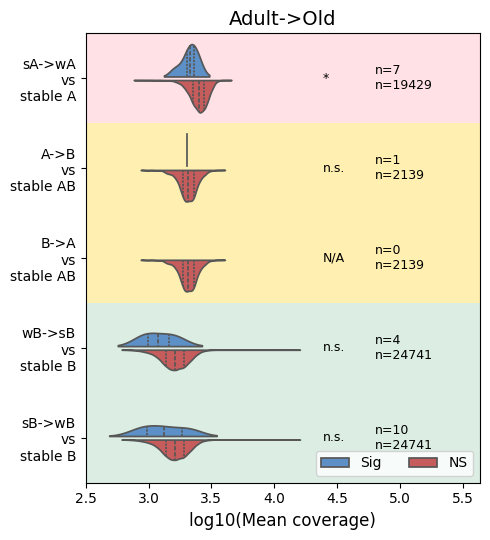

In [31]:
target_control_pairs = {
    'A->B': 'stable_AB',
    'B->A': 'stable_AB',
    'wB->sB': 'stable_B',
    'sB->wB': 'stable_B',
    'sA->wA': 'stable_A'
}

group_colors = {
    'B transitions': '#A8D5BA',      
    'A-B transitions': '#FFD93D',    
    'A transitions': '#FFB6C1'      
}

label_to_group = {
    'wB->sB': 'B transitions', 'sB->wB': 'B transitions', 'stable_B': 'B transitions',
    'A->B': 'A-B transitions', 'B->A': 'A-B transitions', 'stable_AB': 'A-B transitions',
    'sA->wA': 'A transitions', 'stable_A': 'A transitions'
}

paired_data = []
pair_order = ['sA->wA', 'A->B', 'B->A', 'wB->sB', 'sB->wB']  

def get_significance_label(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.0001:
        return '****'
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'n.s.'

stat_results = {}

for target in pair_order:
    control = target_control_pairs[target]
    
    target_data = merged_df[merged_df['Label'] == target]['mean_coverage_log10'].dropna().values
    control_data = merged_df[merged_df['Label'] == control]['mean_coverage_log10'].dropna().values
    n1, n2 = len(target_data), len(control_data)
    
    res_dict = {
        'u_stat': np.nan,
        'p_value': np.nan,
        'effect_size': np.nan,
        'effect_interp': "N/A",
        'n_target': n1,
        'n_control': n2,
        'sig_label': 'N/A',
        'median_target': np.nan,
        'median_control': np.nan
    }
    
    if n1 > 0 and n2 > 0:
        u_stat, p_value = stats.mannwhitneyu(target_data, control_data, alternative='two-sided')
        
        r_effect = 1 - (2 * u_stat) / (n1 * n2) 
        
        if abs(r_effect) < 0.1:
            effect_interp = "negligible"
        elif abs(r_effect) < 0.3:
            effect_interp = "small"
        elif abs(r_effect) < 0.5:
            effect_interp = "medium"
        else:
            effect_interp = "large"
            
        res_dict.update({
            'u_stat': u_stat,
            'p_value': p_value,
            'effect_size': r_effect,
            'effect_interp': effect_interp,
            'sig_label': get_significance_label(p_value),
            'median_target': np.median(target_data),
            'median_control': np.median(control_data)
        })
        
    stat_results[target] = res_dict

valid_raw_p = [stat_results[t]['p_value'] for t in pair_order if pd.notna(stat_results[t]['p_value'])]

if valid_raw_p:
    _, p_adj_vals, _, _ = multipletests(valid_raw_p, alpha=0.05, method='fdr_bh')
    
    adj_idx = 0
    for target in pair_order:
        if pd.notna(stat_results[target]['p_value']):
            p_adj = p_adj_vals[adj_idx]
            stat_results[target]['p_adj'] = p_adj
            # Update the significance label using the ADJUSTED p-value
            stat_results[target]['sig_label'] = get_significance_label(p_adj)
            adj_idx += 1

for target, control in target_control_pairs.items():
    target_df = merged_df[merged_df['Label'] == target].copy()
    target_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    target_df['Type'] = 'Sig'
    paired_data.append(target_df)
    
    control_df = merged_df[merged_df['Label'] == control].copy()
    control_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    control_df['Type'] = 'NS'
    paired_data.append(control_df)

paired_df = pd.concat(paired_data, ignore_index=True)

pair_order_labels = [f"{t}\nvs\n{target_control_pairs[t]}".replace("_", " ") for t in pair_order]
paired_df['Pair'] = pd.Categorical(paired_df['Pair'], categories=pair_order_labels, ordered=True)

fig, ax = plt.subplots(figsize=(5, 5.5))

for i, pair_label in enumerate(pair_order_labels):
    target_name = pair_label.split('\n')[0]
    group = label_to_group.get(target_name)
    if group:
        ax.axhspan(i - 0.5, i + 0.5, facecolor=group_colors[group], alpha=0.4, zorder=0)

sns.violinplot(
    x="mean_coverage_log10", 
    y="Pair", 
    hue="Type",
    data=paired_df, 
    split=True,
    inner = "quart",
    gap=0.1,
    palette={'Sig': '#4A90D9', 'NS': '#D94A4A'},
    ax=ax,
    zorder=1
)

counts = paired_df.groupby(['Pair', 'Type']).size().unstack(fill_value=0)
max_x = paired_df['mean_coverage_log10'].max()

for i, pair_label in enumerate(pair_order_labels):
    if pair_label in counts.index:
        trans_count = counts.loc[pair_label, 'Sig']
        ctrl_count = counts.loc[pair_label, 'NS']
        signif = stat_results[pair_order[i]].get('sig_label')
        ax.text(max_x * 1.05, i, f'{signif}', 
                va='center', ha='left', fontsize=9)
        ax.text(max_x * 1.15, i, f'n={trans_count}\nn={ctrl_count}', 
                va='center', ha='left', fontsize=9)

ax.set_xlim(2.5, max_x * 1.35)

ax.set_title("Adult->Old", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("log10(Mean coverage)", fontsize=12)
ax.legend(title='', loc='lower right', fontsize=10)
ax.legend( 
    loc='lower right',
    ncol=2,     
    fontsize=10
)

plt.tight_layout()
plt.show()

## Mappability analysis

In [32]:
import pyBigWig

In [33]:
umap_data = pd.read_csv("mm10_umap/k100.umap.bedgraph", 
                        sep = "\t", 
                        skiprows=[0], 
                        header=None, 
                        names=['chrom', 'start', 'end', 'score']
                       )

In [34]:
compartments_wt_s6 = pd.read_csv('Adult->S6-KO_bins.csv', index_col=0)
compartments_wt_old = pd.read_csv('Adult->Old_bins.csv', index_col=0)
compartments_wt_s1 = pd.read_csv('Control->Step1_bins.csv', index_col=0)
compartments_wt_s2 = pd.read_csv('Control->Step2_bins.csv', index_col=0)

In [35]:
stable_wt_s6 = pd.read_csv('Adult->S6-KO_stable_bins.csv', index_col=0)
stable_wt_old = pd.read_csv('Adult->Old_stable_bins.csv', index_col=0)
stable_wt_s1 = pd.read_csv('Control->Step1_stable_bins.csv', index_col=0)
stable_wt_s2 = pd.read_csv('Control->Step2_stable_bins.csv', index_col=0)

In [36]:
compartments_wt_s6 = pd.concat([compartments_wt_s6, stable_wt_s6], ignore_index=True)
compartments_wt_old = pd.concat([compartments_wt_old, stable_wt_old], ignore_index=True)
compartments_wt_s1 = pd.concat([compartments_wt_s1, stable_wt_s1], ignore_index=True)
compartments_wt_s2 = pd.concat([compartments_wt_s2, stable_wt_s2], ignore_index=True)

In [37]:
def calculate_bin_mappability(df_bins, df_mapp, read_length=100):
    """
    Average the 1bp mappability scores to 50kb bins
    
    Parameters:
    -----------
    df_bins : DataFrame with columns: chrom, start, end, Label
    df_mapp : DataFrame with columns: chrom, start, end, score
              (where end-start = 1bp)
    read_length : int, read length used for mappability (default 100)
    """
    
    results = []
    
    for chrom in df_bins['chrom'].unique():
        print(f"Processing {chrom}...")
        
        # Get bins for this chromosome
        chrom_bins = df_bins[df_bins['chrom'] == chrom].copy().sort_values('start')
        
        # Get mappability data for this chromosome
        chrom_mapp = df_mapp[df_mapp['chrom'] == chrom].copy().sort_values('start')
        
        if len(chrom_mapp) == 0:
            print(f"  Warning: No mappability data for {chrom}")
            for _, bin_row in chrom_bins.iterrows():
                results.append({
                    'chrom': chrom,
                    'start': bin_row['start'],
                    'end': bin_row['end'],
                    'avg_mappability': np.nan,
                    'n_intervals': 0,
                    'fraction_covered': 0,
                    'Label': bin_row['Label']
                })
            continue
        
        # For each bin, find all 1bp intervals that fall within the valid range
        for _, bin_row in chrom_bins.iterrows():
            bin_start = bin_row['start']
            bin_end = bin_row['end']
            
            # IMPORTANT: For a read of length L, the read starting at position p
            # covers [p, p+L). For it to be fully within the bin, 
            # p must be in [start, end-L]
            valid_start_min = bin_start
            valid_start_max = bin_end - read_length
            
            # Find all 1bp intervals where the start position is in valid range
            # Since your file has 1bp intervals, 'start' column is the position
            mask = (chrom_mapp['start'] >= valid_start_min) & \
                   (chrom_mapp['start'] <= valid_start_max)
            
            bin_mapp = chrom_mapp.loc[mask]
            
            if len(bin_mapp) > 0:
                avg_mapp = bin_mapp['score'].mean()
                n_intervals = len(bin_mapp)
                # Total possible positions in valid range
                total_possible = valid_start_max - valid_start_min + 1
                fraction_covered = n_intervals / total_possible if total_possible > 0 else 0
            else:
                avg_mapp = np.nan
                n_intervals = 0
                fraction_covered = 0
            
            results.append({
                'chrom': chrom,
                'start': bin_start,
                'end': bin_end,
                'avg_mappability': avg_mapp,
                'n_intervals': n_intervals,
                'fraction_covered': fraction_covered,
                'Label': bin_row['Label']
            })
    
    return pd.DataFrame(results)

In [39]:
df_wt_s6 = calculate_bin_mappability(compartments_wt_s6, umap_data)
df_wt_old = calculate_bin_mappability(compartments_wt_old, umap_data)
df_wt_s1 = calculate_bin_mappability(compartments_wt_s1, umap_data)
df_wt_s2 = calculate_bin_mappability(compartments_wt_s2, umap_data)

Processing chr1...
Processing chr2...
Processing chr3...
Processing chr4...
Processing chr6...
Processing chr9...
Processing chr10...
Processing chr14...
Processing chr16...
Processing chr18...
Processing chr5...
Processing chr13...
Processing chr19...
Processing chr7...
Processing chr12...
Processing chr8...
Processing chr11...
Processing chr15...
Processing chr17...
Processing chr12...
Processing chr5...
Processing chr9...
Processing chr18...
Processing chr7...
Processing chr17...
Processing chr19...
Processing chr1...
Processing chr2...
Processing chr3...
Processing chr4...
Processing chr6...
Processing chr8...
Processing chr10...
Processing chr11...
Processing chr13...
Processing chr14...
Processing chr15...
Processing chr16...
Processing chr1...
Processing chr2...
Processing chr3...
Processing chr4...
Processing chr5...
Processing chr6...
Processing chr7...
Processing chr8...
Processing chr9...
Processing chr10...
Processing chr11...
Processing chr12...
Processing chr13...
Process

In [41]:
df_wt_old.head()

,chrom,start,end,avg_mappability,n_intervals,fraction_covered,Label
0,chr12,3200000,3250000,0.696020,5573,0.111681,stable_AB
1,chr12,3250000,3300000,0.697789,1135,0.022745,stable_A
2,chr12,3300000,3350000,0.618463,1958,0.039238,stable_A
3,chr12,3350000,3400000,0.730686,583,0.011683,stable_A
4,chr12,3400000,3450000,0.746532,2742,0.054949,stable_A


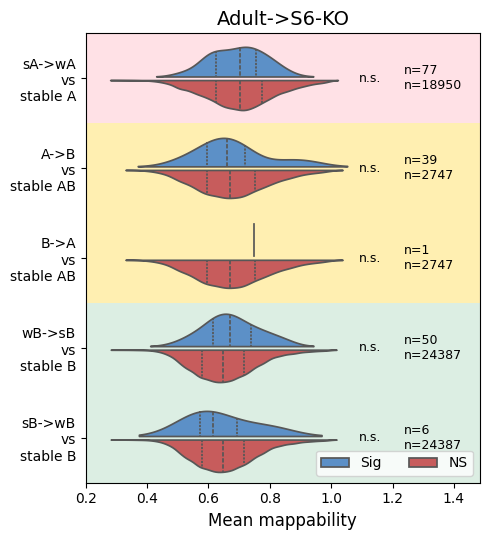

In [42]:

target_control_pairs = {
    'A->B': 'stable_AB',
    'B->A': 'stable_AB',
    'wB->sB': 'stable_B',
    'sB->wB': 'stable_B',
    'sA->wA': 'stable_A'
}


group_colors = {
    'B transitions': '#A8D5BA',      # Light green
    'A-B transitions': '#FFD93D',    # Yellow
    'A transitions': '#FFB6C1'       # Light pink
}

label_to_group = {
    'wB->sB': 'B transitions', 'sB->wB': 'B transitions', 'stable_B': 'B transitions',
    'A->B': 'A-B transitions', 'B->A': 'A-B transitions', 'stable_AB': 'A-B transitions',
    'sA->wA': 'A transitions', 'stable_A': 'A transitions'
}


paired_data = []
pair_order = ['sA->wA', 'A->B', 'B->A', 'wB->sB', 'sB->wB']  # Order for plotting

def get_significance_label(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.0001:
        return '****'
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'n.s.'

stat_results = {}

for target in pair_order:
    control = target_control_pairs[target]
    
    target_data = df_wt_s6[df_wt_s6['Label'] == target]['avg_mappability'].dropna().values
    control_data = df_wt_s6[df_wt_s6['Label'] == control]['avg_mappability'].dropna().values
    n1, n2 = len(target_data), len(control_data)
    
    res_dict = {
        'u_stat': np.nan,
        'p_value': np.nan,
        'effect_size': np.nan,
        'effect_interp': "N/A",
        'n_target': n1,
        'n_control': n2,
        'sig_label': 'N/A',
        'median_target': np.nan,
        'median_control': np.nan
    }
    
    if n1 > 0 and n2 > 0:
        u_stat, p_value = stats.mannwhitneyu(target_data, control_data, alternative='two-sided')
        
        r_effect = 1 - (2 * u_stat) / (n1 * n2) 
        
        # Effect size interpretation
        if abs(r_effect) < 0.1:
            effect_interp = "negligible"
        elif abs(r_effect) < 0.3:
            effect_interp = "small"
        elif abs(r_effect) < 0.5:
            effect_interp = "medium"
        else:
            effect_interp = "large"
            
        res_dict.update({
            'u_stat': u_stat,
            'p_value': p_value,
            'effect_size': r_effect,
            'effect_interp': effect_interp,
            'sig_label': get_significance_label(p_value),
            'median_target': np.median(target_data),
            'median_control': np.median(control_data)
        })
        
    stat_results[target] = res_dict

valid_raw_p = [stat_results[t]['p_value'] for t in pair_order if pd.notna(stat_results[t]['p_value'])]

if valid_raw_p:
    _, p_adj_vals, _, _ = multipletests(valid_raw_p, alpha=0.05, method='fdr_bh')
    
    adj_idx = 0
    for target in pair_order:
        if pd.notna(stat_results[target]['p_value']):
            p_adj = p_adj_vals[adj_idx]
            stat_results[target]['p_adj'] = p_adj
            stat_results[target]['sig_label'] = get_significance_label(p_adj)
            adj_idx += 1


for target, control in target_control_pairs.items():
    target_df = df_wt_s6[df_wt_s6['Label'] == target].copy()
    target_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    target_df['Type'] = 'Sig'
    paired_data.append(target_df)
    
    control_df = df_wt_s6[df_wt_s6['Label'] == control].copy()
    control_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    control_df['Type'] = 'NS'
    paired_data.append(control_df)

paired_df = pd.concat(paired_data, ignore_index=True)

pair_order_labels = [f"{t}\nvs\n{target_control_pairs[t]}".replace("_", " ") for t in pair_order]
paired_df['Pair'] = pd.Categorical(paired_df['Pair'], categories=pair_order_labels, ordered=True)

fig, ax = plt.subplots(figsize=(5, 5.5))

for i, pair_label in enumerate(pair_order_labels):
    target_name = pair_label.split('\n')[0]
    group = label_to_group.get(target_name)
    if group:
        ax.axhspan(i - 0.5, i + 0.5, facecolor=group_colors[group], alpha=0.4, zorder=0)

sns.violinplot(
    x="avg_mappability", 
    y="Pair", 
    hue="Type",
    data=paired_df, 
    split=True,
    inner = "quart",
    gap=0.1,
    palette={'Sig': '#4A90D9', 'NS': '#D94A4A'},
    ax=ax,
    zorder=1
)

counts = paired_df.groupby(['Pair', 'Type']).size().unstack(fill_value=0)
max_x = paired_df['avg_mappability'].max()


for i, pair_label in enumerate(pair_order_labels):
    if pair_label in counts.index:
        trans_count = counts.loc[pair_label, 'Sig']
        ctrl_count = counts.loc[pair_label, 'NS']
        signif = stat_results[pair_order[i]].get('sig_label')
        ax.text(max_x * 1.1, i, f'{signif}', 
                va='center', ha='left', fontsize=9)
        ax.text(max_x * 1.25, i, f'n={trans_count}\nn={ctrl_count}', 
                va='center', ha='left', fontsize=9)
        
        


ax.set_xlim(0.2, max_x * 1.5)

ax.set_title("Adult->S6-KO", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("Mean mappability", fontsize=12)
ax.legend(title='', loc='lower right', fontsize=10)
ax.legend( 
    loc='lower right',
    ncol=2,     
    fontsize=10
)

plt.tight_layout()
plt.show()

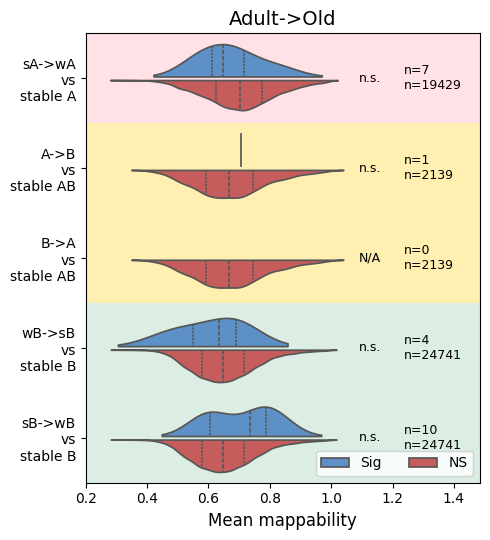

In [43]:
target_control_pairs = {
    'A->B': 'stable_AB',
    'B->A': 'stable_AB',
    'wB->sB': 'stable_B',
    'sB->wB': 'stable_B',
    'sA->wA': 'stable_A'
}

group_colors = {
    'B transitions': '#A8D5BA',      # Light green
    'A-B transitions': '#FFD93D',    # Yellow
    'A transitions': '#FFB6C1'       # Light pink
}

label_to_group = {
    'wB->sB': 'B transitions', 'sB->wB': 'B transitions', 'stable_B': 'B transitions',
    'A->B': 'A-B transitions', 'B->A': 'A-B transitions', 'stable_AB': 'A-B transitions',
    'sA->wA': 'A transitions', 'stable_A': 'A transitions'
}

paired_data = []
pair_order = ['sA->wA', 'A->B', 'B->A', 'wB->sB', 'sB->wB']  # Order for plotting

def get_significance_label(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.0001:
        return '****'
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'n.s.'

stat_results = {}

for target in pair_order:
    control = target_control_pairs[target]
    
    target_data = df_wt_old[df_wt_old['Label'] == target]['avg_mappability'].dropna().values
    control_data = df_wt_old[df_wt_old['Label'] == control]['avg_mappability'].dropna().values
    n1, n2 = len(target_data), len(control_data)
    
    res_dict = {
        'u_stat': np.nan,
        'p_value': np.nan,
        'effect_size': np.nan,
        'effect_interp': "N/A",
        'n_target': n1,
        'n_control': n2,
        'sig_label': 'N/A',
        'median_target': np.nan,
        'median_control': np.nan
    }
    
    if n1 > 0 and n2 > 0:
        u_stat, p_value = stats.mannwhitneyu(target_data, control_data, alternative='two-sided')
        
        r_effect = 1 - (2 * u_stat) / (n1 * n2) 
        
        if abs(r_effect) < 0.1:
            effect_interp = "negligible"
        elif abs(r_effect) < 0.3:
            effect_interp = "small"
        elif abs(r_effect) < 0.5:
            effect_interp = "medium"
        else:
            effect_interp = "large"
            
        res_dict.update({
            'u_stat': u_stat,
            'p_value': p_value,
            'effect_size': r_effect,
            'effect_interp': effect_interp,
            'sig_label': get_significance_label(p_value),
            'median_target': np.median(target_data),
            'median_control': np.median(control_data)
        })
        
    stat_results[target] = res_dict

valid_raw_p = [stat_results[t]['p_value'] for t in pair_order if pd.notna(stat_results[t]['p_value'])]

if valid_raw_p:
    _, p_adj_vals, _, _ = multipletests(valid_raw_p, alpha=0.05, method='fdr_bh')
    
    adj_idx = 0
    for target in pair_order:
        if pd.notna(stat_results[target]['p_value']):
            p_adj = p_adj_vals[adj_idx]
            stat_results[target]['p_adj'] = p_adj
            # Update the significance label using the ADJUSTED p-value
            stat_results[target]['sig_label'] = get_significance_label(p_adj)
            adj_idx += 1

for target, control in target_control_pairs.items():
    target_df = df_wt_old[df_wt_old['Label'] == target].copy()
    target_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    target_df['Type'] = 'Sig'
    paired_data.append(target_df)
    
    control_df = df_wt_old[df_wt_old['Label'] == control].copy()
    control_df['Pair'] = f"{target}\nvs\n{control}".replace("_", " ")
    control_df['Type'] = 'NS'
    paired_data.append(control_df)

paired_df = pd.concat(paired_data, ignore_index=True)

pair_order_labels = [f"{t}\nvs\n{target_control_pairs[t]}".replace("_", " ") for t in pair_order]
paired_df['Pair'] = pd.Categorical(paired_df['Pair'], categories=pair_order_labels, ordered=True)

fig, ax = plt.subplots(figsize=(5, 5.5))

for i, pair_label in enumerate(pair_order_labels):
    target_name = pair_label.split('\n')[0]
    group = label_to_group.get(target_name)
    if group:
        ax.axhspan(i - 0.5, i + 0.5, facecolor=group_colors[group], alpha=0.4, zorder=0)

sns.violinplot(
    x="avg_mappability", 
    y="Pair", 
    hue="Type",
    data=paired_df, 
    split=True,
    inner = "quart",
    gap=0.1,
    palette={'Sig': '#4A90D9', 'NS': '#D94A4A'},
    ax=ax,
    zorder=1
)

counts = paired_df.groupby(['Pair', 'Type']).size().unstack(fill_value=0)
max_x = paired_df['avg_mappability'].max()

for i, pair_label in enumerate(pair_order_labels):
    if pair_label in counts.index:
        trans_count = counts.loc[pair_label, 'Sig']
        ctrl_count = counts.loc[pair_label, 'NS']
        signif = stat_results[pair_order[i]].get('sig_label')
        ax.text(max_x * 1.1, i, f'{signif}', 
                va='center', ha='left', fontsize=9)
        ax.text(max_x * 1.25, i, f'n={trans_count}\nn={ctrl_count}', 
                va='center', ha='left', fontsize=9)

ax.set_xlim(0.2, max_x * 1.5)

ax.set_title("Adult->Old", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("Mean mappability", fontsize=12)
ax.legend(title='', loc='lower right', fontsize=10)
ax.legend( 
    loc='lower right',
    ncol=2,     
    fontsize=10
)

plt.tight_layout()
plt.show()